# E2 Assessment

# Part 1 - Flat data and headers

In [7]:
import pandas as pd

# specify your file path
df = pd.read_csv("for_nitpicker.dat", sep="\t", header=None)
df.columns = ["date", "time", "depth", "temperature(°C)", "salinity(psu)"]
df.to_csv("output.csv", index=False)

In [8]:
df.head()

,date,time,depth,temperature(°C),salinity(psu)
0,11/29/2008,06:52,5,28.97,35.21
1,11/29/2008,06:52,6,28.98,35.21
2,11/29/2008,06:52,7,28.99,35.21
3,11/29/2008,06:52,8,28.96,35.21
4,11/29/2008,06:52,9,28.99,35.21


## Part 2: profiles

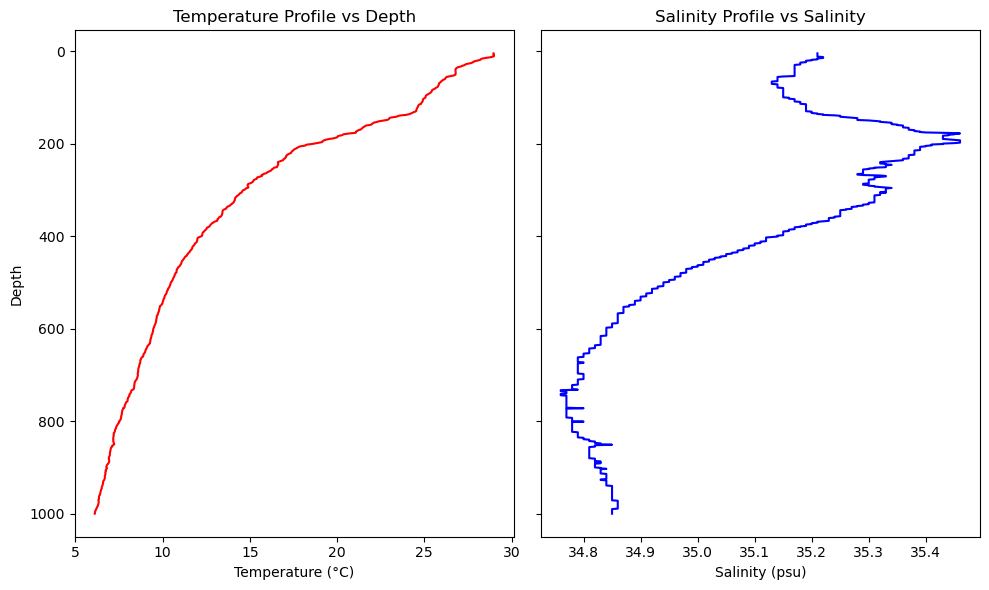

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your prepared CSV
df = pd.read_csv("output.csv")

# Create two panels (side by side) with shared y-axis
fig, axes = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(10, 6))

# --- Temperature profile ---
axes[0].plot(df["temperature(°C)"], df["depth"], color="red")
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("Depth")
axes[0].set_title("Temperature Profile vs Depth")

# --- Salinity profile ---
axes[1].plot(df["salinity(psu)"], df["depth"], color="blue")
axes[1].set_xlabel("Salinity (psu)")
axes[1].set_title("Salinity Profile vs Salinity")

# Invert depth axis (important for profiles)
axes[0].invert_yaxis()

# Improve layout
plt.tight_layout()

# Show the plot
plt.show()

## Part 3: 

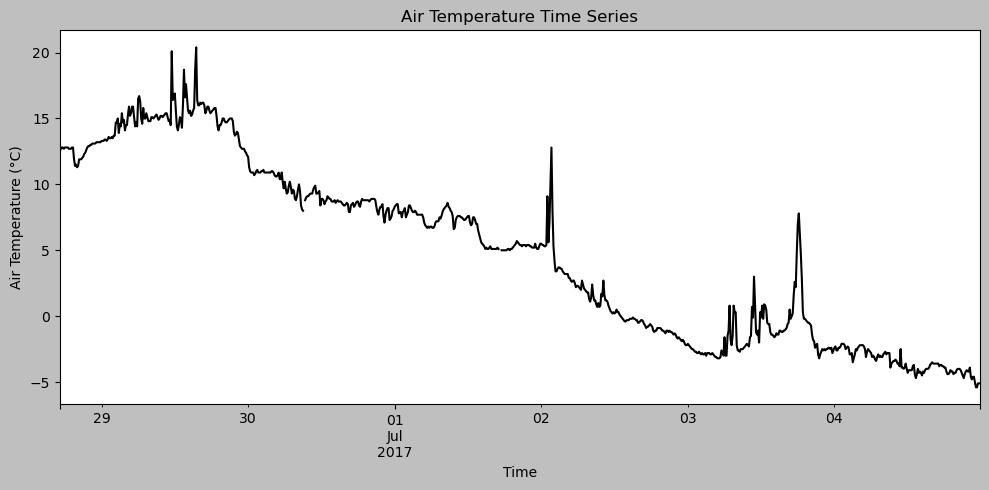

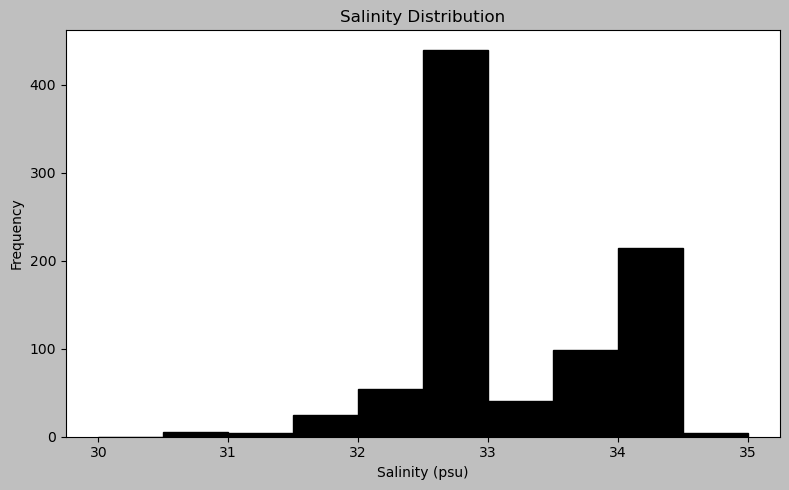

                           Mean   Std Dev        IQR
Air Temperature (°C)   4.878271  6.692847  11.675000
Salinity (psu)        33.110553  1.140150   1.272575


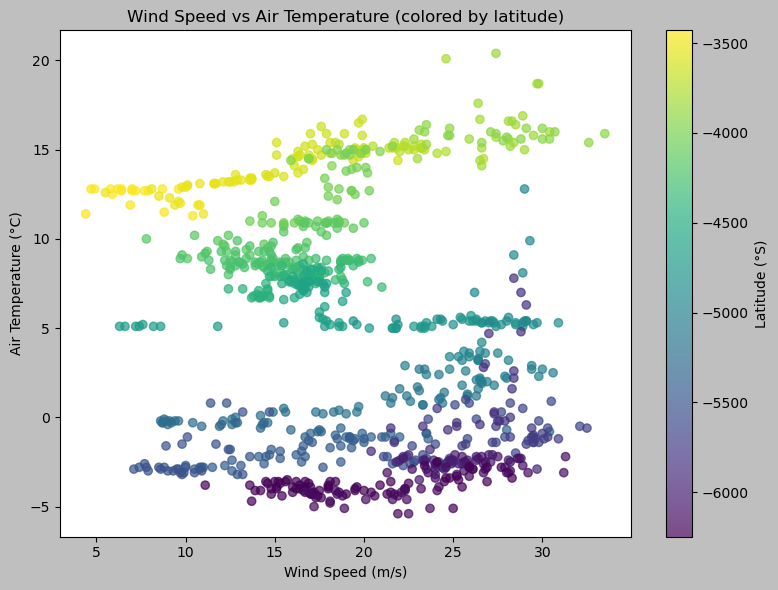

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the CSV file with time index
df = pd.read_csv("SAA2_WC_2017_metocean_10min_avg.csv", parse_dates=["TIME_SERVER"], na_values=["NULL"])
df.set_index("TIME_SERVER", inplace=True)

# 2. Select data from departure until July 4th (inclusive)
end_date = "2017-07-04"
df_sel = df.loc[:end_date]

# 3. Plot time series of air temperature
plt.style.use("grayscale")
plt.figure(figsize=(10, 5))
df_sel["AIR_TEMPERATURE"].plot()
plt.xlabel("Time")
plt.ylabel("Air Temperature (°C)")
plt.title("Air Temperature Time Series")
plt.tight_layout()
plt.savefig("temperature_timeseries.png", dpi=300)
plt.show()

# 4. Histogram of salinity distribution
plt.figure(figsize=(8, 5))
bins = np.arange(30, 35.5, 0.5)
df_sel["TSG_SALINITY"].dropna().plot.hist(bins=bins, edgecolor="black")
plt.xlabel("Salinity (psu)")
plt.ylabel("Frequency")
plt.title("Salinity Distribution")
plt.tight_layout()
plt.savefig("salinity_histogram.png", dpi=300)
plt.show()

# 5. Calculate statistics for temperature and salinity
def iqr(series):
    return series.quantile(0.75) - series.quantile(0.25)

stats = pd.DataFrame({
    "Mean": [df_sel["AIR_TEMPERATURE"].mean(), df_sel["TSG_SALINITY"].mean()],
    "Std Dev": [df_sel["AIR_TEMPERATURE"].std(), df_sel["TSG_SALINITY"].std()],
    "IQR": [iqr(df_sel["AIR_TEMPERATURE"]), iqr(df_sel["TSG_SALINITY"])]
}, index=["Air Temperature (°C)", "Salinity (psu)"])

print(stats)

# 6. Scatter plot of wind speed vs air temperature, colored by latitude
plt.figure(figsize=(8, 6))
sc = plt.scatter(df_sel["WIND_SPEED_TRUE"], df_sel["AIR_TEMPERATURE"],
                 c=-df_sel["LATITUDE"].astype(str).str[:-1].astype(float), cmap="viridis", alpha=0.7)
plt.colorbar(sc, label="Latitude (°S)")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Air Temperature (°C)")
plt.title("Wind Speed vs Air Temperature (colored by latitude)")
plt.tight_layout()
plt.savefig("wind_temp_scatter.png", dpi=300)
plt.show()